<a href="https://colab.research.google.com/github/ghanha0a/hand-write-numbers-CNN/blob/main/hand_write_num_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [48]:
!pip.install tensorflow
from keras.models import Sequential
from keras.layers import Dense
import tensorflow as tf
from tensorflow import keras



/bin/bash: line 1: pip.install: command not found


In [2]:
minst =tf.keras.datasets.mnist

In [3]:
(x_train,y_train),(x_test,y_test)=minst.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [4]:
x_train = x_train / 255.0
x_test = x_test / 255.0

In [5]:
print(x_train.shape)
print(y_train.shape)
print(x_test.shape)
print(y_test.shape)

(60000, 28, 28)
(60000,)
(10000, 28, 28)
(10000,)


[[0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.    

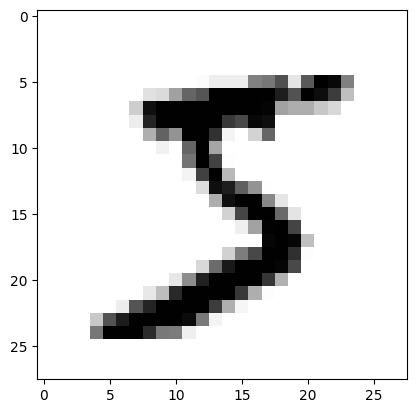

In [6]:
print(x_train[0])
import matplotlib.pyplot as plt
plt.imshow(x_train[0] , cmap= plt.cm.binary)
print(y_train[0])

In [7]:
x_train = x_train.reshape(x_train.shape[0], 28, 28, 1)
x_test = x_test.reshape(x_test.shape[0], 28, 28, 1)

#model.add(tf.keras.Input(shape=(28, 28, 1)))
#model.add(tf.keras.layers.Conv2D(32, (3, 3), activation='relu'))
#model.add(tf.keras.layers.MaxPooling2D((2, 2)))
model = tf.keras.Sequential()

model.add(tf.keras.layers.Conv2D(32, (3, 3), activation='relu',input_shape=(28,28,1)))

model.add(tf.keras.layers.MaxPooling2D((2, 2)))

model.add(keras.layers.Flatten())

model.add(tf.keras.layers.Dense(128, activation='relu'))
model.add(tf.keras.layers.Dropout(0.2)) # Added Dropout layer
model.add(tf.keras.layers.Dense(10, activation='softmax'))


model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

history= model.fit(x_train,y_train,epochs=10, validation_data=(x_test, y_test), callbacks=[tf.keras.callbacks.EarlyStopping(monitor='val_loss',patience=1)],shuffle=False)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 50s 26ms/step - accuracy: 0.9469 - loss: 0.1809 - val_accuracy: 0.9740 - val_loss: 0.0741
Epoch 2/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 44s 24ms/step - accuracy: 0.9803 - loss: 0.0653 - val_accuracy: 0.9804 - val_loss: 0.0566
Epoch 3/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 82s 24ms/step - accuracy: 0.9865 - loss: 0.0434 - val_accuracy: 0.9854 - val_loss: 0.0437
Epoch 4/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 45s 24ms/step - accuracy: 0.9902 - loss: 0.0314 - val_accuracy: 0.9862 - val_loss: 0.0412
Epoch 5/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 43s 23ms/step - accuracy: 0.9920 - loss: 0.0238 - val_accuracy: 0.9869 - val_loss: 0.0443


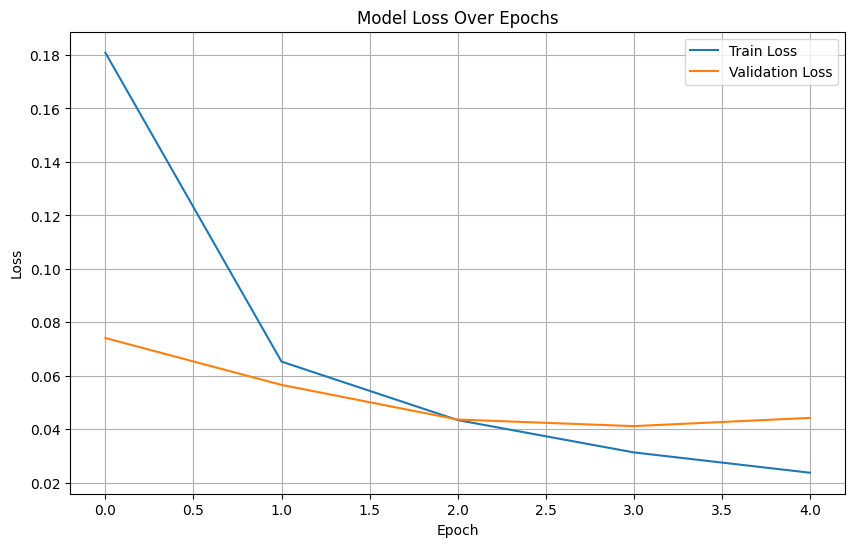

In [10]:
import matplotlib.pyplot as plt

# Plot training & validation loss values
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss Over Epochs')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(loc='upper right')
plt.grid(True)
plt.show()

In [11]:
val_loss, val_acc = model.evaluate(x_test, y_test)
print(val_loss)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9869 - loss: 0.0443
0.044267311692237854


uplpoad pic to predict:


Saving test_image_1.png to test_image_1 (2).png
file upload "test_image_1 (2).png" perfctly.


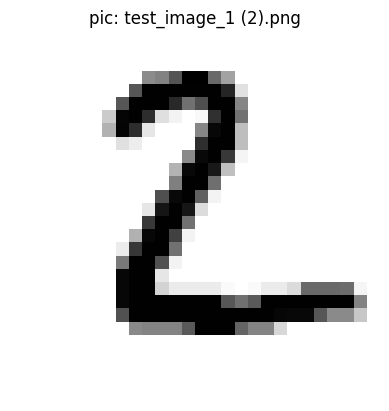

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
pic predict  test_image_1 (2).png: 2 (probability: 1.0000)


In [60]:
from google.colab import files
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

def predict_image(image_path):
    try:
        custom_img = Image.open(image_path).convert('L')
        custom_img = custom_img.resize((28, 28))
        custom_img_array = np.array(custom_img) / 255.0
        custom_img_array_reshaped = custom_img_array.reshape(1, 28, 28, 1)

        plt.imshow(custom_img_array, cmap=plt.cm.binary)
        plt.title(f"pic: {image_path}")
        plt.axis('off')
        plt.show()

        custom_prediction = model.predict(custom_img_array_reshaped)
        predicted_label = np.argmax(custom_prediction)
        probability = np.max(custom_prediction)

        return predicted_label, probability
    except FileNotFoundError:
        print(f"\n pic  '{image_path}' not found.")
        return None, None
    except Exception as e:
        print(f"\n  eroor  : {e}")
        return None, None

# Upload an image
print("uplpoad pic to predict:")
uploaded = files.upload()

for fn in uploaded.keys():
    print(f'file upload "{fn}" perfctly.')
    predicted_class, probability = predict_image(fn)
    if predicted_class is not None:
        print(f"pic predict  {fn}: {predicted_class} (probability: {probability:.4f})")

In [15]:
# Save the entire model to a .keras file
model.save('my_mnist_cnn_model.keras')

print("Model saved to my_mnist_cnn_model.keras")

Model saved to my_mnist_cnn_model.keras
